# Coupled ABM — FloodAdapt × DYNAMO-M — practical guide

## 1. Introduction and context

### 1.1 Context and aim of the coupling project

The FloodAdapt-ABM coupling project integrates the physical flood risk modelling of FloodAdapt (using SFINCS and FIAT) with the behavioural agent-based modelling of DYNAMO-M. The goal is to provide a comprehensive framework to assess how household-level adaptation decisions (like floodproofing) evolve dynamically alongside rising sea levels and stochastic flood events over time.

### 1.2 Aim of this notebook

This notebook serves as the canonical Stage-3 runner for simulating adaptation. It demonstrates how to initialize the simulation engine, configure the Subjective Expected Utility (SEU) decision rules, run the simulation, and visualize the adaptation outcomes over a multi-decade horizon.

### 1.3 What falls under minimum viable product (MVP)

The MVP for this coupling bridges the core SEU decision kernel from DYNAMO-M. It evaluates how agents perceive risk based on recent flood events, calculates their expected utility for taking action, and applies affordability constraints. However, it specifically excludes broader DYNAMO-M features such as the gravity models (for migration), regional economic feedbacks, and non-monetary amenities. These are reserved for future phases.

### 1.4 Why a lightweight `AgentState` instead of full DYNAMO-M

Instead of spinning up the massive DYNAMO-M ecosystem (which involves parsing gigabytes of geospatial data and instantiating memory-heavy `CoastalNode` instances for every building), this engine uses a lightweight `AgentState` array structure. This allows us to load only the exact property values, damage estimates, and event probabilities needed for the SEU logic from the NetCDF lookup table. This ensures the simulation runs rapidly (in seconds instead of hours) while remaining mathematically bit-for-bit identical to the native DYNAMO-M execution.

### 1.5 Documentation guide: what to read next?

If you want to understand this project deeply, we recommend reading the documentation in this order:
1. **`README.md`** (Root directory) — Start here for the quick-start guide, installation instructions, and a high-level overview of the pipeline.
2. **`docs/architecture.md`** — The canonical design record detailing the coupling architecture, the SEU mathematical formulation, and the Phase phase-gate history.
3. **`floodadapt_abm_documentation.md`** — The comprehensive API reference covering every module, class, and configuration dataclass in the repository.

## 2. Main workflow steps shared among ABM methods
### 2.1 Setup

In [23]:
import sys, os, platform
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Make floodadapt_abm importable and reuse the examples' dataset loader.
_REPO = Path.cwd()
sys.path.insert(0, str(_REPO))
sys.path.insert(0, str(_REPO / "examples_engine"))
from _shared import load_dataset  # noqa: E402

import floodadapt_abm as fabm
from floodadapt_abm import (
    SimulationEngine, CouplingConfig, DecisionConfig,
    SEURule, ThresholdRule, DynamoLiveRule,
    run_mesa_native, run_mesa_native_full,
    DYNAMO_M_AVAILABLE, HONEYBEES_AVAILABLE,
)

print("Python           :", platform.python_version())
print("numpy / xarray   :", np.__version__, "/", xr.__version__)
print("honeybees present:", HONEYBEES_AVAILABLE, " (real Mesa/honeybees run path)")
print("DYNAMO-M present :", DYNAMO_M_AVAILABLE, " (native DecisionModule parity)")

Python           : 3.11.14
numpy / xarray   : 1.26.4 / 2025.11.0
honeybees present: True  (real Mesa/honeybees run path)
DYNAMO-M present : True  (native DecisionModule parity)


### 2.2 Helper functions (for plotting, data processing, etc.)

In [ ]:
def create_summary_table(n_adapted, adoption, damage, base_damage, no_seq):
    import pandas as pd
    import numpy as np
    
    dmg_year = damage.sum(axis=1) / 1e6
    avoided_year = np.clip(base_damage - damage, 0, None).sum(axis=1) / 1e6
    
    summary = pd.DataFrame({
        "sequence":            [f"seq {s}" for s in range(no_seq)],
        "final adopted (#)":   n_adapted[:, -1],
        "final adopted (%)":   (adoption[:, -1] * 100).round(1),
        "cum. damage (M$)":    dmg_year.sum(axis=1).round(1),
        "cum. avoided (M$)":   avoided_year.sum(axis=1).round(1),
    })
    agg = pd.DataFrame({
        "sequence": ["MEAN", "STD"],
        "final adopted (#)":   [n_adapted[:, -1].mean().round(1),  n_adapted[:, -1].std().round(1)],
        "final adopted (%)":   [(adoption[:, -1]*100).mean().round(1), (adoption[:, -1]*100).std().round(1)],
        "cum. damage (M$)":    [dmg_year.sum(axis=1).mean().round(1),  dmg_year.sum(axis=1).std().round(1)],
        "cum. avoided (M$)":   [avoided_year.sum(axis=1).mean().round(1), avoided_year.sum(axis=1).std().round(1)],
    })
    return pd.concat([summary, agg], ignore_index=True), dmg_year, avoided_year

def plot_results(years, slr_values, n_adapted, dmg_year, avoided_year, no_seq):
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
    slr_color = "#6c757d"

    def overlay_slr(ax):
        axr = ax.twinx()
        axr.plot(years, slr_values, color=slr_color, ls="--", lw=1.8, label="SLR trajectory")
        axr.set_ylabel("Sea-level rise (table units)", color=slr_color)
        axr.tick_params(axis="y", labelcolor=slr_color)
        axr.set_ylim(bottom=min(0, float(slr_values.min())))
        return axr

    metrics = [
        (n_adapted, "(a) Households adapted per year", "# households floodproofed", "C0"),
        (dmg_year, "(b) Total flood damage per year", "Damage (M$)", "C1"),
        (avoided_year, "(c) Avoided damage per year (vs never-adapt)", "Avoided damage (M$)", "C2")
    ]
    
    for i, (data, title, ylabel, color) in enumerate(metrics):
        ax = axes[i]
        for s in range(no_seq):
            ax.plot(years, data[s], color=color, alpha=0.30, lw=1, label="individual sequence" if s == 0 else "")
        m, sd = data.mean(0), data.std(0)
        ax.plot(years, m, color=color, lw=2.4, label="mean (across sequences)")
        ax.fill_between(years, np.maximum(0, m - sd), m + sd, color=color, alpha=0.20, label="±1 s.d. uncertainty")
        ax.set_title(title)
        ax.set_xlabel("Year"); ax.set_ylabel(ylabel)
        axr = overlay_slr(ax)
        lines_ax, labels_ax = ax.get_legend_handles_labels()
        lines_axr, labels_axr = axr.get_legend_handles_labels()
        ax.legend(lines_ax + lines_axr, labels_ax + labels_axr, loc="upper left")

    fig.suptitle(f"Coupled ABM outcomes under rising SLR — {no_seq} sequences, mean ±1 s.d.", y=1.03)
    fig.tight_layout()
    plt.show()

def print_insights(slr_values, years, adoption, dmg_year, avoided_year, no_seq):
    final_adopt_pct = adoption[:, -1].mean() * 100
    peak_dmg   = dmg_year.mean(0).max()
    cum_dmg    = dmg_year.sum(1).mean()
    cum_avoid  = avoided_year.sum(1).mean()
    avoid_share = 100 * cum_avoid / (cum_dmg + cum_avoid) if (cum_dmg + cum_avoid) > 0 else 0.0

    print("KEY TAKEAWAYS")
    print("-" * 68)
    n_years = len(years)
    print(f"* Sea level rises from {slr_values[0]:.2f} to {slr_values[-1]:.2f} over {n_years} yr.")
    print(f"* By year {years[-1]}, on average {final_adopt_pct:.0f}% of households have floodproofed.")
    print(f"* Peak mean annual flood damage is about ${peak_dmg:.1f}M.")
    print(f"* Over the horizon, adaptation avoids ~${cum_avoid:.0f}M of damage")
    print(f"  (~{avoid_share:.0f}% of what damage would otherwise have been).")
    print(f"* Spread across the {no_seq} sequences is the uncertainty from stochastic flood timing.")

### 2.3 The coupled architecture, concisely

### 2.4 Monte-Carlo sequences and multiprocessing

### 2.5 Configuration

In [24]:
# --- Scenario ---------------------------------------------------------------
START_YEAR         = 2020
N_YEARS            = 30
NO_SEQ             = 5          # Monte-Carlo sequences
MAX_EVENTS_PER_YR  = 5
SEED               = 42

# --- Dataset Selection: Synthetic vs. Real Charleston Table ----------------
# OPTION 1: Run on the fast SYNTHETIC table (runs in seconds) - DEFAULT
# USE_REAL_TABLE = False

# OPTION 2: Run on the real 2GB CHARLESTON table (takes several minutes)
USE_REAL_TABLE = True

# OPTION 3: Control via environment variable (useful for CI/automated runs)
# USE_REAL_TABLE = os.environ.get("FA_ABM_REAL_TABLE", "0").lower() in ("1", "true", "yes")

ds, source = load_dataset(prefer_real=USE_REAL_TABLE)
print(f"Lookup table : {source}")
print(f"dimensions   : {dict(ds.sizes)}")

# --- Decision / coupling configuration --------------------------------------
config = CouplingConfig(
    decision=DecisionConfig(max_events_per_year=MAX_EVENTS_PER_YR),  # lifespan_dryproof=75 default
    random_seed=SEED,
)

# --- SLR trajectory (the driver) --------------------------------------------
# Preferred, if a FloodAdapt database is available:
#   import flood_adapt.api as fa
#   slr_values = np.array([fa.interp_slr(slr_scenario="NOAA High", year=START_YEAR+t)
#                          for t in range(N_YEARS)])


# Fallback: a linear ramp across the lookup table's SLR grid.
slr_values = np.linspace(float(ds.slr.min()), float(ds.slr.max()), N_YEARS)
years = START_YEAR + np.arange(N_YEARS)
print(f"SLR trajectory: {slr_values[0]:.2f} -> {slr_values[-1]:.2f} "
      f"({ds.slr.attrs.get('units', 'table units')}) over {N_YEARS} years")


Lookup table : real Charleston table (lookup_table_charleston_beta_release_ABM_probabilistic_set.nc)
dimensions   : {'object_id': 61858, 'slr': 5, 'strategy': 2, 'event': 207}
SLR trajectory: 0.00 -> 2.00 (table units) over 30 years


## 3. Main ABM execution methods
### 3.1 Preferred run — `run_mesa_native_full` (honeybees-driven)

In [25]:
engine = SimulationEngine(ds=ds, config=config)
print(f"residential agents: {engine.n_agents}")

# Prefer the native DYNAMO-M decision module when available; else the ported SEURule.
if DYNAMO_M_AVAILABLE:
    engine.decision_rule = DynamoLiveRule(config.decision)
    rule_label = "native DYNAMO-M DecisionModule (DynamoLiveRule)"
else:
    engine.decision_rule = SEURule(config.decision)
    rule_label = "ported SEURule (DYNAMO-M SEU math)"
print("decision rule    :", rule_label)

# Preferred honeybees-driven run; portable mirror if honeybees is absent.
if HONEYBEES_AVAILABLE:
    run_label = "run_mesa_native_full (real honeybees Model clock)"
    results = run_mesa_native_full(engine, slr_values, no_seq=NO_SEQ, seed=SEED,
                                   track_eu=True, start_year=START_YEAR)
else:
    run_label = "run_mesa_native (dependency-free mirror; honeybees not installed)"
    results = run_mesa_native(engine, slr_values, no_seq=NO_SEQ, seed=SEED, track_eu=True)
print("run path         :", run_label)

damage   = results["damage_history"].astype(np.float64)   # (NO_SEQ, n_agents, N_YEARS)
adopted  = results["adapted_history"]                      # bool, same shape
adoption = results["adoption_fraction"]                    # (NO_SEQ, N_YEARS)
n_adapted = adopted.sum(axis=1)                            # (NO_SEQ, N_YEARS) households adapted
print("result arrays    :", {k: v.shape for k, v in results.items() if hasattr(v, "shape")})

residential agents: 57976
decision rule    : native DYNAMO-M DecisionModule (DynamoLiveRule)
run path         : run_mesa_native_full (real honeybees Model clock)
result arrays    : {'damage_history': (5, 57976, 30), 'adapted_history': (5, 57976, 30), 'adoption_fraction': (5, 30), 'eu_adapt_history': (5, 57976, 30), 'eu_do_nothing_history': (5, 57976, 30)}


## 4. Result comparison and visualisation
### 4.1 Results per sequence and statistics

In [26]:
# Never-adapt baseline on the SAME event sequences (identical seeds).
baseline_engine = SimulationEngine(
    ds=ds,
    config=CouplingConfig(decision=DecisionConfig(max_events_per_year=MAX_EVENTS_PER_YR,
                                                  lifespan_dryproof=None),
                          random_seed=SEED),
    decision_rule=ThresholdRule(config.decision, damage_threshold=1.01),
)
baseline = baseline_engine.run(slr_values, no_seq=NO_SEQ, seed=SEED)
base_damage = baseline["damage_history"].astype(np.float64)

summary_table, dmg_year, avoided_year = create_summary_table(n_adapted, adoption, damage, base_damage, NO_SEQ)
summary_table

,sequence,final adopted (#),final adopted (%),cum. damage (M$),cum. avoided (M$)
0,seq 0,5003.0,8.6,891.7,2719.0
1,seq 1,4741.0,8.2,265.7,2433.0
2,seq 2,4629.0,8.0,409.6,2677.5
3,seq 3,5142.0,8.9,320.1,2711.0
4,seq 4,5155.0,8.9,1432.3,3022.9
5,MEAN,4934.0,8.5,663.9,2712.7
6,STD,213.1,0.4,443.6,187.5


### 4.2 Visualisation — read against rising sea level

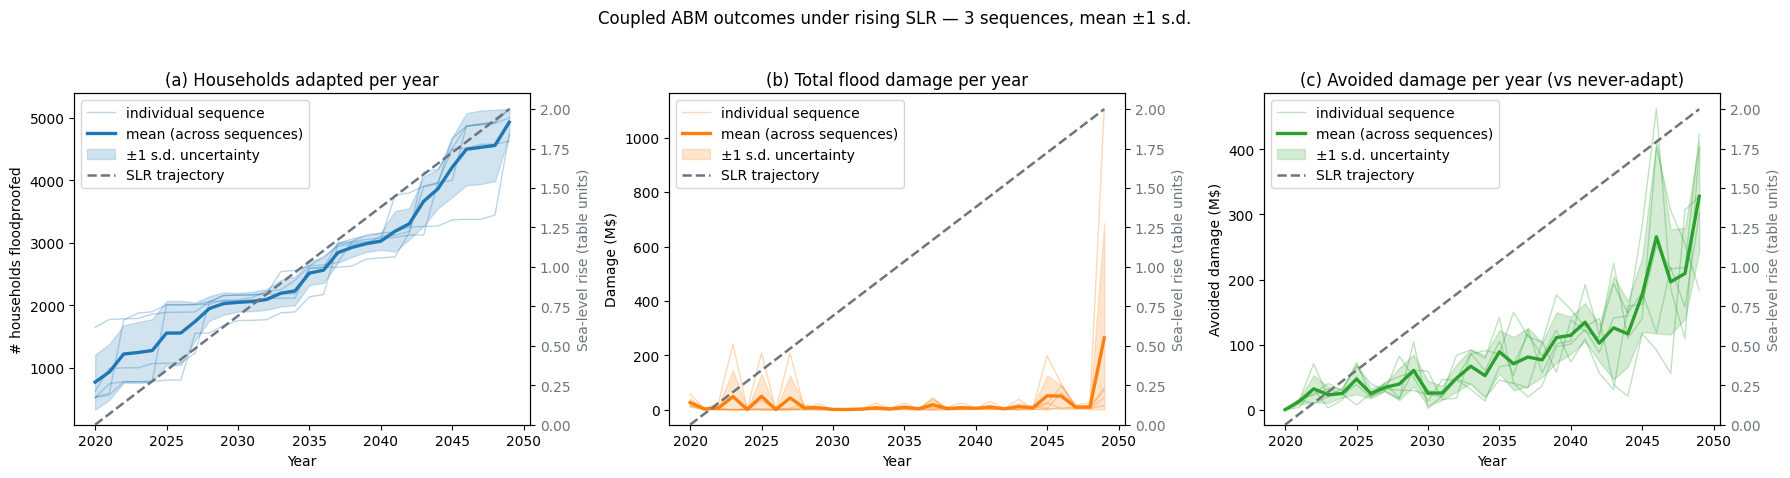

In [27]:
plot_results(years, slr_values, n_adapted, dmg_year, avoided_year, NO_SEQ)

## 5. General insights for policy making
### 5.1 Insights

In [29]:
print_insights(slr_values, years, adoption, dmg_year, avoided_year, NO_SEQ)

KEY TAKEAWAYS
--------------------------------------------------------------------
* Sea level rises from 0.00 to 2.00 over 30 yr.
* By year 2049, on average 9% of households have floodproofed.
* Peak mean annual flood damage is about $264.0M.
* Over the horizon, adaptation avoids ~$2713M of damage
  (~80% of what damage would otherwise have been).
* Spread across the 5 sequences is the uncertainty from stochastic flood timing.


### 3.2 The native mirror — same results without mesa/honeybees

PARITY OK: run_mesa_native  ==  engine.run(n_jobs=-1)  ==  Section-6 run  (bit-for-bit)


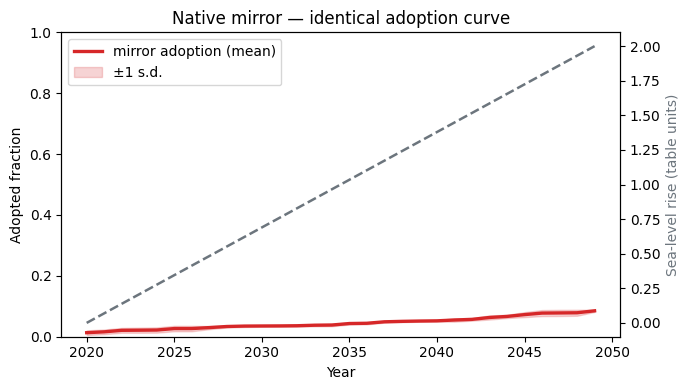

In [ ]:
# Portable mirror (no honeybees needed) and the parallel engine — same seeds.
mirror   = run_mesa_native(engine, slr_values, no_seq=NO_SEQ, seed=SEED, track_eu=True)
parallel = engine.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)

# Bit-for-bit equality is the coupling's correctness contract.
assert np.array_equal(mirror["damage_history"],  results["damage_history"]),  "mirror != preferred"
assert np.array_equal(mirror["adapted_history"], results["adapted_history"]), "mirror != preferred"
assert np.array_equal(parallel["damage_history"],  results["damage_history"]),  "parallel != preferred"
assert np.array_equal(parallel["adapted_history"], results["adapted_history"]), "parallel != preferred"
print("PARITY OK: run_mesa_native  ==  engine.run(n_jobs=-1)  ==  Section-6 run  (bit-for-bit)")

# Same headline (adoption) from the mirror, with SLR overlaid.
mad = mirror["adoption_fraction"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(years, mad.mean(0), color="C3", lw=2.4, label="mirror adoption (mean)")
ax.fill_between(years, np.maximum(0, mad.mean(0) - mad.std(0)), mad.mean(0) + mad.std(0), color="C3", alpha=0.2, label="±1 s.d.")
ax.set_xlabel("Year"); ax.set_ylabel("Adopted fraction"); ax.set_ylim(0, 1)
ax.set_title("Native mirror — identical adoption curve"); ax.legend(loc="upper left")
axr = ax.twinx(); axr.plot(years, slr_values, color="#6c757d", ls="--", lw=1.8)
axr.set_ylabel("Sea-level rise (table units)", color="#6c757d")
plt.tight_layout(); plt.show()

### 3.3 Extend and configure (Strategy Pattern)